Michel Spectrum Subtraction

In [1]:
import numpy as np
import matplotlib.pyplot as plt

file1 = '/raid1/genli/Data_D2O/M1_data/analysis_24531-24585_M1_20250730-193838/MASTER_RESULTS/Master_Runs_24531_24585_M1_total_pe.pkl'
file2 = '/raid1/genli/Data_D2O/M2_data/analysis_396-450_M2_20250730-195909/MASTER_RESULTS/Master_Runs_396_450_M2_total_pe.pkl'

data1 = np.load(file1, allow_pickle=True)
data2 = np.load(file2, allow_pickle=True)

print(data1)

centers1 = data1['centers']
centers2 = data2['centers']
sum_area1 = data1['hist']
sum_area2 = data2['hist']
err1 = data1['errors']
err2 = data2['errors']

{'centers': array([  10.,   30.,   50.,   70.,   90.,  110.,  130.,  150.,  170.,
        190.,  210.,  230.,  250.,  270.,  290.,  310.,  330.,  350.,
        370.,  390.,  410.,  430.,  450.,  470.,  490.,  510.,  530.,
        550.,  570.,  590.,  610.,  630.,  650.,  670.,  690.,  710.,
        730.,  750.,  770.,  790.,  810.,  830.,  850.,  870.,  890.,
        910.,  930.,  950.,  970.,  990., 1010., 1030., 1050., 1070.,
       1090., 1110., 1130., 1150., 1170., 1190., 1210., 1230., 1250.,
       1270., 1290., 1310., 1330., 1350., 1370., 1390., 1410., 1430.,
       1450., 1470., 1490., 1510., 1530., 1550., 1570., 1590., 1610.,
       1630., 1650., 1670., 1690., 1710., 1730., 1750., 1770., 1790.,
       1810., 1830., 1850., 1870., 1890., 1910., 1930., 1950., 1970.,
       1990.]), 'hist': array([  392, 12921, 36483, 43763, 47797, 50539, 51312, 50150, 46465,
       39586, 31698, 25057, 20015, 15723, 12906, 10403,  8478,  6824,
        5437,  4476,  3744,  3110,  2609,  2148,  1808

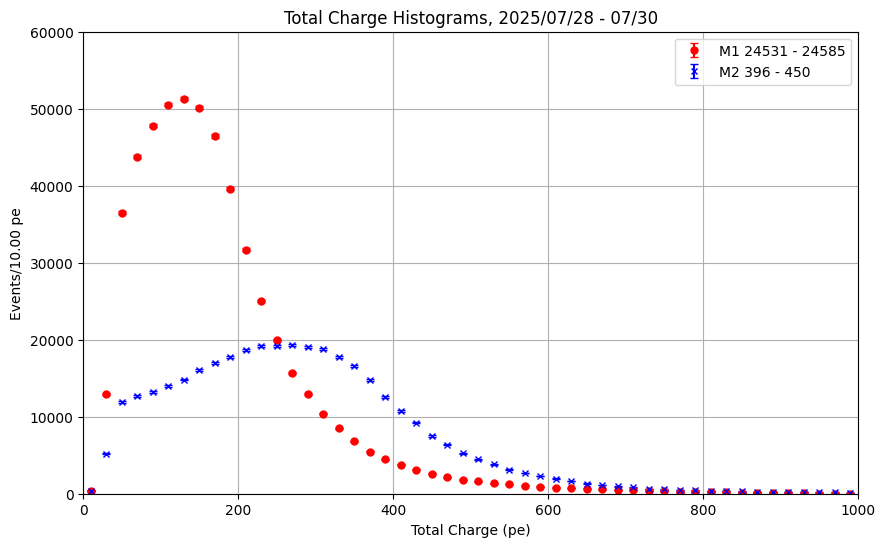

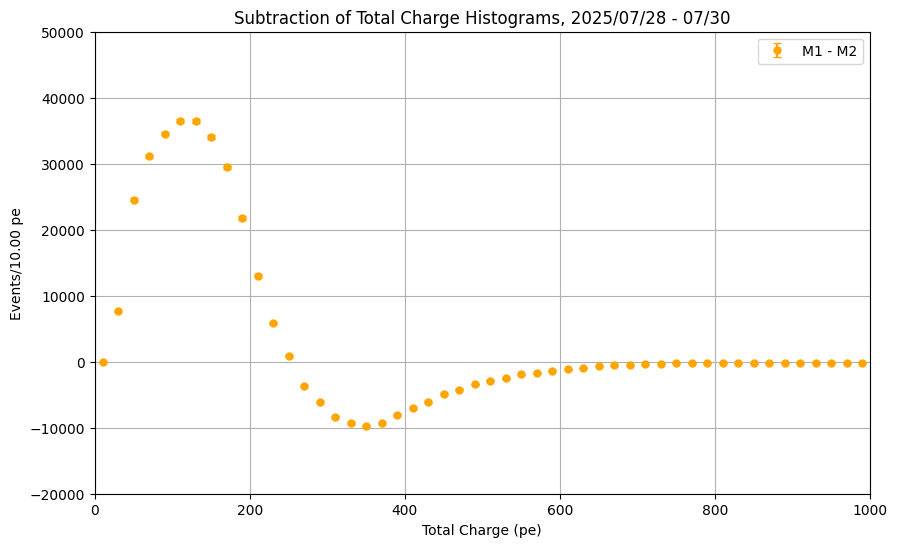

In [2]:
#Normalize the histograms and errors
# Convert to float to avoid casting errors
sum_area1 = sum_area1.astype(float)
sum_area2 = sum_area2.astype(float)
err1 = err1.astype(float)
err2 = err2.astype(float)
err_total = np.sqrt(err1**2 + err2**2)
bin_step = 1000 / centers1.size  # Assuming centers1 and centers2 have the same size
#plotting hist1 and hist2 on the same plot
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1, yerr=err1, fmt='o', label='M1 24531 - 24585', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, sum_area2, yerr=err2, fmt='x', label='M2 396 - 450', color='blue', markersize=5, capsize=3)
plt.title('Total Charge Histograms, 2025/07/28 - 07/30')
plt.xlabel('Total Charge (pe)')
plt.ylabel(f'Events/{bin_step:.2f} pe')  # Adjusted ylabel to include bin step
plt.ylim(0, 60000)
plt.xlim(0, 1000)
plt.legend()
plt.grid()
# plt.savefig('total_charge_histograms.png')
plt.show()

#plotting subtraction hist1 - hist2
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, sum_area1 - sum_area2, yerr=err_total, fmt='o', label='M1 - M2', color='orange', markersize=5, capsize=3)
plt.title('Subtraction of Total Charge Histograms, 2025/07/28 - 07/30')
plt.xlabel('Total Charge (pe)')
plt.ylabel(f'Events/{bin_step:.2f} pe')  # Adjusted ylabel to include bin step
plt.ylim(-20000, 50000)
plt.xlim(0, 1000)
plt.legend()
plt.grid()
# plt.savefig('subtraction_histograms.png')
plt.show()

In [3]:
print("M1 events number:", np.sum(sum_area1))
print("M2 events number:", np.sum(sum_area2))
print("Subtraction events number:", np.sum(sum_area1 - sum_area2))

M1 events number: 545652.0
M2 events number: 368174.0
Subtraction events number: 177478.0


Muon veto efficiency

{'centers': array([  50.,  150.,  250.,  350.,  450.,  550.,  650.,  750.,  850.,
        950., 1050., 1150., 1250., 1350., 1450., 1550., 1650., 1750.,
       1850., 1950.]), 'efficiency': array([0.80890487, 0.82716414, 0.90240366, 0.94800304, 0.97074296,
       0.97310311, 0.97593698, 0.96943441, 0.9792719 , 0.99888687,
       0.99941951, 0.99954399, 0.99963702, 0.99974539, 0.99975521,
       0.99981563, 0.99984999, 0.99984511, 0.99992108, 0.99986152]), 'error': array([3.71752075e-04, 2.95226074e-04, 2.44000644e-04, 1.82165994e-04,
       1.39578297e-04, 1.34190206e-04, 1.25041695e-04, 1.36873909e-04,
       1.13684791e-04, 2.77090939e-05, 2.14491913e-05, 2.09183790e-05,
       2.07466321e-05, 1.93551059e-05, 2.08353402e-05, 1.95414989e-05,
       1.92056814e-05, 2.16877149e-05, 1.76455295e-05, 2.76935431e-05]), 'counts_2': array([213742, 283498, 144373,  77238,  42651,  39095,  36142,  48344,
        32555,   1612,    732,    475,    306,    173,    138,     89,
           61,     51

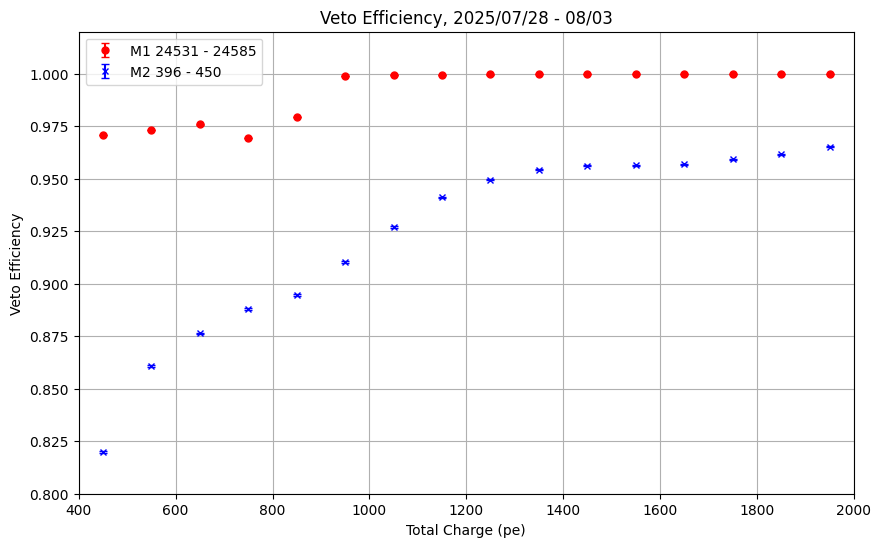

In [4]:
m1_file = '/raid1/genli/Data_D2O/M1_data/analysis_24531-24585_M1_20250730-193838/MASTER_RESULTS/Master_Runs_24531_24585_M1_veto_efficiency_master.pkl'
m2_file = '/raid1/genli/Data_D2O/M2_data/analysis_396-450_M2_20250730-195909/MASTER_RESULTS/Master_Runs_396_450_M2_veto_efficiency_master.pkl'
m1_data = np.load(m1_file, allow_pickle=True)
m2_data = np.load(m2_file, allow_pickle=True)

print(m1_data)
centers1 = m1_data['centers']
centers2 = m2_data['centers']
veto_eff1 = m1_data['efficiency']
veto_eff2 = m2_data['efficiency']
err1 = m1_data['error']
err2 = m2_data['error']

#plotting veto efficiency
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, veto_eff1, yerr=err1, fmt='o', label='M1 24531 - 24585', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, veto_eff2, yerr=err2, fmt='x', label='M2 396 - 450', color='blue', markersize=5, capsize=3)
plt.title('Veto Efficiency, 2025/07/28 - 08/03')
plt.xlabel('Total Charge (pe)')
plt.ylabel('Veto Efficiency')
plt.ylim(0.8, 1.02)
plt.xlim(400, 2000)
plt.legend()
plt.grid()
# plt.savefig('veto_efficiency.png')
plt.show()

{'centers': array([  50.,  150.,  250.,  350.,  450.,  550.,  650.,  750.,  850.,
        950., 1050., 1150., 1250., 1350., 1450., 1550., 1650., 1750.,
       1850., 1950.]), 'efficiency': array([0.51062736, 0.70042709, 0.72382759, 0.76013942, 0.81810771,
       0.85796155, 0.87337703, 0.89003322, 0.89856856, 0.90889703,
       0.92647548, 0.93951026, 0.95305529, 0.95340412, 0.95848104,
       0.95769922, 0.95931618, 0.96078793, 0.96312066, 0.96452199]), 'error': array([0.00302873, 0.00292144, 0.00311845, 0.003103  , 0.0029435 ,
       0.00274034, 0.00264012, 0.00255015, 0.0024297 , 0.00234912,
       0.00212896, 0.00193936, 0.00170089, 0.00166578, 0.00154632,
       0.00155798, 0.00152473, 0.00152287, 0.00152535, 0.00157727]), 'counts_2': array([13331,  7365,  5677,  4542,  3124,  2305,  2009,  1655,  1566,
        1367,  1105,   914,   726,   746,   691,   706,   683,   637,
         563,   488]), 'counts_2_or_34': array([27241, 24585, 20556, 18936, 17175, 16228, 15866, 15050, 15439,

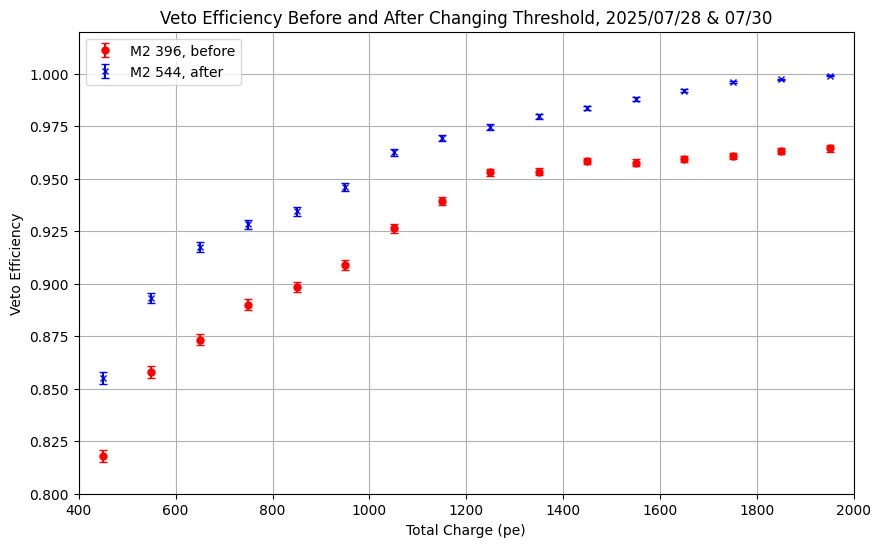

In [5]:
file1 = '/raid1/genli/Data_D2O/M2_data/analysis_396-397_M2_20250804-160852/subjob_396-396/run396_20250728-08/histograms/396_M2_veto_efficiency.pkl'
file2 = '/raid1/genli/Data_D2O/M2_data/analysis_544-545_M2_20250804-160336/subjob_544-544/run544_20250803-13/histograms/544_M2_veto_efficiency.pkl'
data1 = np.load(file1, allow_pickle=True)
data2 = np.load(file2, allow_pickle=True)

print(data1)
centers1 = data1['centers']
centers2 = data2['centers']
veto_eff1 = data1['efficiency']
veto_eff2 = data2['efficiency']
err1 = data1['error']
err2 = data2['error']

#plotting veto efficiency
plt.figure(figsize=(10, 6))
plt.errorbar(centers1, veto_eff1, yerr=err1, fmt='o', label='M2 396, before', color='red', markersize=5, capsize=3)
plt.errorbar(centers2, veto_eff2, yerr=err2, fmt='x', label='M2 544, after', color='blue', markersize=5, capsize=3)
plt.title('Veto Efficiency Before and After Changing Threshold, 2025/07/28 & 07/30')
plt.xlabel('Total Charge (pe)')
plt.ylabel('Veto Efficiency')
plt.ylim(0.8, 1.02)
plt.xlim(400, 2000)
plt.legend()
plt.grid()
# plt.savefig('veto_efficiency.png')
plt.show()

Trigger Bits

{'centers': array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
       11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
       22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
       33.5, 34.5]), 'histograms': {'triggerBits': array([8.20000e+02, 0.00000e+00, 9.21949e+05, 0.00000e+00, 2.15711e+05,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 2.15702e+05, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 2.15697e+05, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 0.00000e+00, 6.80910e+05, 0.00000e+00, 4.05039e+05])}}


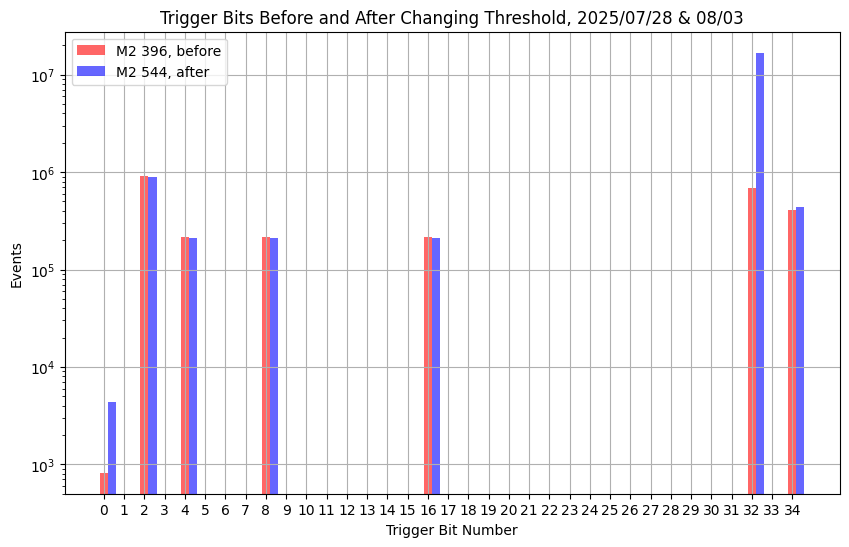

In [6]:
file1_triggerbit = '/raid1/genli/Data_D2O/M2_data/analysis_396-397_M2_20250804-160852/subjob_396-396/run396_20250728-08/histograms/396_M2_triggerBits.pkl'
file2_triggerbit = '/raid1/genli/Data_D2O/M2_data/analysis_544-545_M2_20250804-160336/subjob_544-544/run544_20250803-13/histograms/544_M2_triggerBits.pkl'
triggerbit1 = np.load(file1_triggerbit, allow_pickle=True)
triggerbit2 = np.load(file2_triggerbit, allow_pickle=True)
print(triggerbit1)
centers1_trigger = triggerbit1['centers']
centers2_trigger = triggerbit2['centers']
triggerbit1_hist = triggerbit1['histograms']['triggerBits']
triggerbit2_hist = triggerbit2['histograms']['triggerBits']

#plotting trigger bits
plt.figure(figsize=(10, 6))
#x axis is the trigger bit number
triggerbits = list(range(0,35))
plt.bar(triggerbits, triggerbit1_hist, width=0.4, label='M2 396, before', color='red', alpha=0.6, align='center')
plt.bar(np.array(triggerbits) + 0.4, triggerbit2_hist, width=0.4, label='M2 544, after', color='blue', alpha=0.6, align='center')
plt.title('Trigger Bits Before and After Changing Threshold, 2025/07/28 & 08/03')
plt.xlabel('Trigger Bit Number')
plt.ylabel('Events')
plt.xticks(np.arange(0, 35, 1))
plt.yscale('log', base=10)  # Use logarithmic scale for better visibility
# plt.ylim(0, 100000)
plt.legend()
plt.grid()
# plt.savefig('trigger_bits.png')
plt.show()

Thin Panel Troubleshooting

{'centers': array([  25.,   75.,  125.,  175.,  225.,  275.,  325.,  375.,  425.,
        475.,  525.,  575.,  625.,  675.,  725.,  775.,  825.,  875.,
        925.,  975., 1025., 1075., 1125., 1175., 1225., 1275., 1325.,
       1375., 1425., 1475., 1525., 1575., 1625., 1675., 1725., 1775.,
       1825., 1875., 1925., 1975., 2025., 2075., 2125., 2175., 2225.,
       2275., 2325., 2375., 2425., 2475., 2525., 2575., 2625., 2675.,
       2725., 2775., 2825., 2875., 2925., 2975., 3025., 3075., 3125.,
       3175., 3225., 3275., 3325., 3375., 3425., 3475., 3525., 3575.,
       3625., 3675., 3725., 3775., 3825., 3875., 3925., 3975., 4025.,
       4075., 4125., 4175., 4225., 4275., 4325., 4375., 4425., 4475.,
       4525., 4575., 4625., 4675., 4725., 4775., 4825., 4875., 4925.,
       4975.]), 'histograms': {'Muon Events (Coincidence)': array([4.33343364e-05, 1.21175644e-04, 2.39542582e-04, 4.13949911e-04,
       9.26070820e-04, 1.54465510e-03, 2.13809476e-03, 2.16390812e-03,
       1.8009161

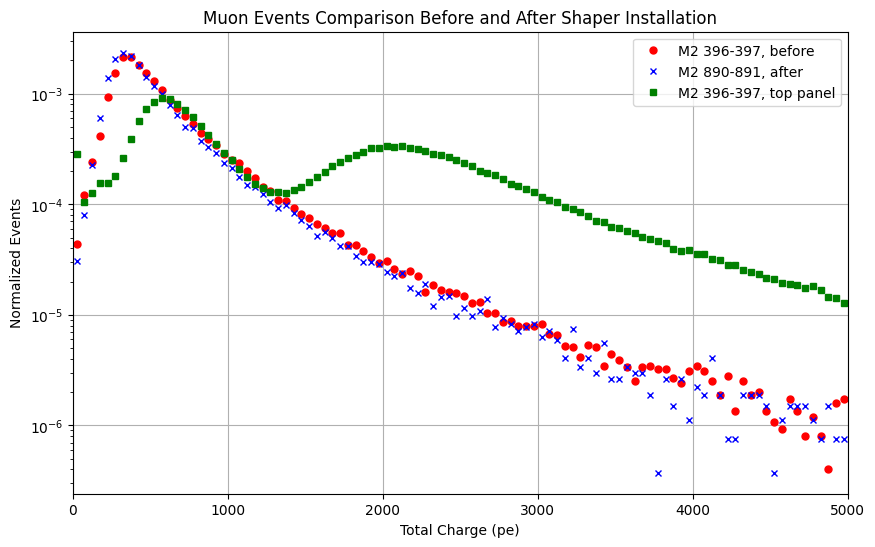

In [11]:
#comapre before and after shaper, also compare with top panel
data_area_before = '/raid1/genli/Data_D2O/M2_data/analysis_396-397_M2_20250820-220724/MASTER_RESULTS/Master_Runs_396_397_M2_thin_veto_area_comparison_master.pkl'
data_area_after = '/raid1/genli/Data_D2O/M2_data/analysis_890-891_M2_20250819-213833/MASTER_RESULTS/Master_Runs_890_891_M2_thin_veto_area_comparison_master.pkl'
data_area_top = '/raid1/genli/Data_D2O/M2_data/analysis_396-397_M2_20250820-220918/MASTER_RESULTS/Master_Runs_396_397_M2_thin_veto_area_comparison_master.pkl'

# Load the data
area_before = np.load(data_area_before, allow_pickle=True)
area_after = np.load(data_area_after, allow_pickle=True)
area_top = np.load(data_area_top, allow_pickle=True)

print(area_before)
centers = area_before['centers']
muon_before = area_before['histograms']['Muon Events (Coincidence)']
muon_after = area_after['histograms']['Muon Events (Coincidence)']
muon_top = area_top['histograms']['Muon Events (Coincidence)']

# Plotting the muon events before, after, and top panel
plt.figure(figsize=(10, 6))
plt.errorbar(centers, muon_before, fmt='o', label='M2 396-397, before', color='red', markersize=5, capsize=3)
plt.errorbar(centers, muon_after, fmt='x', label='M2 890-891, after', color='blue', markersize=5, capsize=3)
plt.errorbar(centers, muon_top, fmt='s', label='M2 396-397, top panel', color='green', markersize=5, capsize=3)
plt.title('Muon Events Comparison Before and After Shaper Installation')
plt.xlabel('Total Charge (pe)') 
plt.ylabel('Normalized Events')
plt.xlim(0, 5000)
plt.yscale('log', base=10)
plt.legend()
plt.grid()
# plt.savefig('muon_events_comparison.png')
plt.show()

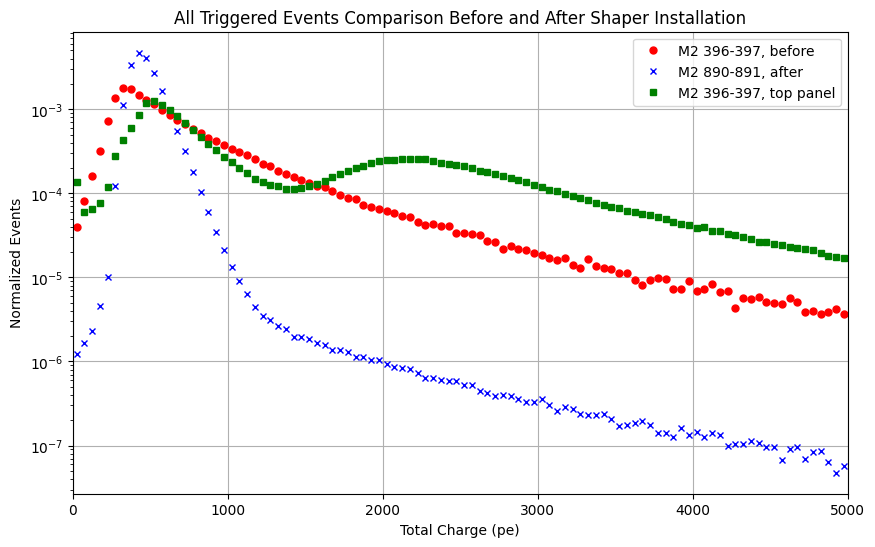

In [12]:
All_before = area_before['histograms']['All Triggered Events']
All_after = area_after['histograms']['All Triggered Events']
All_top = area_top['histograms']['All Triggered Events']

# Plotting the All events before, after, and top panel
plt.figure(figsize=(10, 6))
plt.errorbar(centers, All_before, fmt='o', label='M2 396-397, before', color='red', markersize=5, capsize=3)
plt.errorbar(centers, All_after, fmt='x', label='M2 890-891, after', color='blue', markersize=5, capsize=3)
plt.errorbar(centers, All_top, fmt='s', label='M2 396-397, top panel', color='green', markersize=5, capsize=3)
plt.title('All Triggered Events Comparison Before and After Shaper Installation')
plt.xlabel('Total Charge (pe)') 
plt.ylabel('Normalized Events')
plt.xlim(0, 5000)
plt.yscale('log', base=10)
plt.legend()
plt.grid()
# plt.savefig('All_events_comparison.png')
plt.show()

{'centers': array([  50.,  150.,  250.,  350.,  450.,  550.,  650.,  750.,  850.,
        950., 1050., 1150., 1250., 1350., 1450., 1550., 1650., 1750.,
       1850., 1950.]), 'efficiency': array([0.80878454, 0.82698606, 0.90233296, 0.94780673, 0.97068238,
       0.97301988, 0.97595439, 0.96947183, 0.97928091, 0.99887776,
       0.99938906, 0.99953698, 0.99963378, 0.99971614, 0.9997254 ,
       0.99982986, 0.99983657, 0.99988002, 0.99992494, 0.99991219]), 'error': array([4.67507863e-04, 3.71514589e-04, 3.06897949e-04, 2.29568265e-04,
       1.75727858e-04, 1.69017395e-04, 1.57168110e-04, 1.72064104e-04,
       1.42919386e-04, 3.49992006e-05, 2.76759901e-05, 2.65065044e-05,
       2.62206491e-05, 2.56961479e-05, 2.77348821e-05, 2.35925251e-05,
       2.52163990e-05, 2.39941069e-05, 2.16659366e-05, 2.77655819e-05]), 'counts_2': array([135301, 179353,  91385,  48992,  27018,  24794,  22844,  30518,
        20581,   1027,    487,    305,    195,    122,     98,     52,
           42,     25

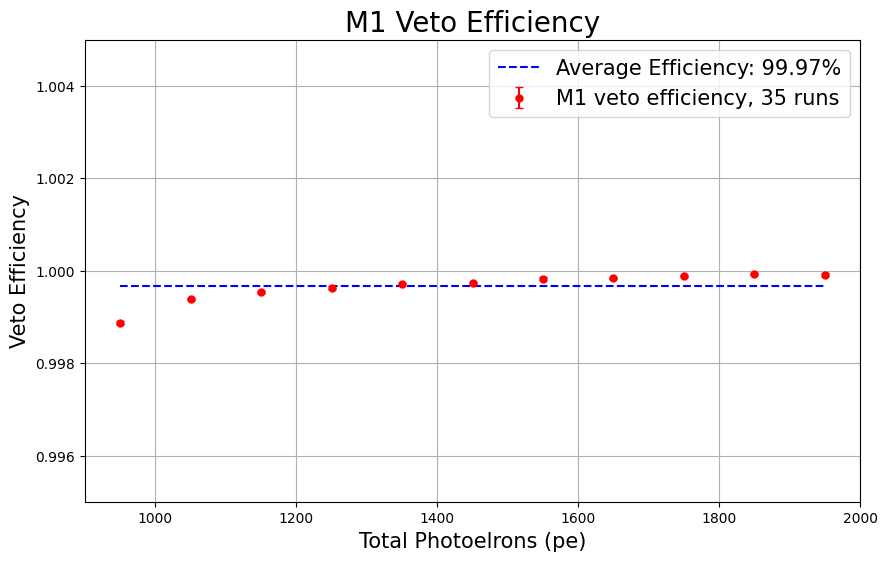

In [15]:
import numpy as np
import matplotlib.pyplot as plt
#load /raid1/genli/Data_D2O/M1_data/analysis_24531-24565_M1_20251017-180538/MASTER_RESULTS/Master_Runs_24531_24565_M1_veto_efficiency_master.pkl
efficplotpath = '/raid1/genli/Data_D2O/M1_data/analysis_24531-24565_M1_20251017-180538/MASTER_RESULTS/Master_Runs_24531_24565_M1_veto_efficiency_master.pkl'
data_eff = np.load(efficplotpath, allow_pickle=True)
print(data_eff)
#make a mask with centers > 1000
mask = data_eff['centers'] > 900
centers_eff = data_eff['centers'][mask]
veto_eff = data_eff['efficiency'][mask]
err_eff = data_eff['error'][mask]
average_eff = np.mean(veto_eff)
#plotting veto efficiency
plt.figure(figsize=(10, 6))
plt.errorbar(centers_eff, veto_eff, yerr=err_eff, fmt='o', label='M1 veto efficiency, 35 runs', color='red', markersize=5, capsize=3)
plt.hlines(average_eff, xmin=centers_eff[0], xmax=centers_eff[-1], colors='blue', linestyles='dashed', label=f'Average Efficiency: {100*average_eff:.2f}%')
plt.title('M1 Veto Efficiency', fontsize=20)
plt.xlabel('Total Photoelrons (pe)', fontsize=15)
plt.ylabel('Veto Efficiency', fontsize=15)
plt.ylim(0.995, 1.005)
plt.legend(fontsize=15)
plt.grid()





Lead Background Analysis

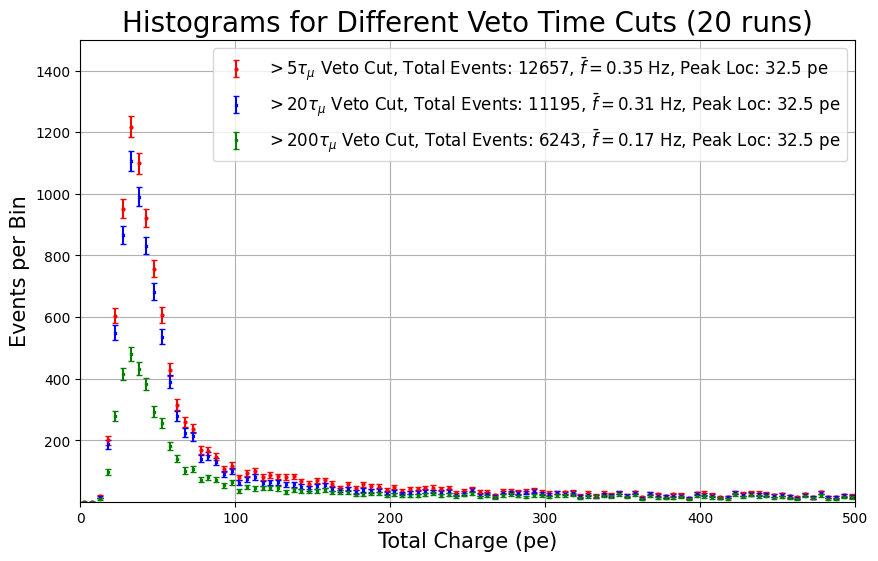

In [ ]:
#Apply different long dt cuts and plot the histograms. 
#After apply that, since it happens from 06/01/2025, so it is in beam-off period and only non-beam background events are expected.
import numpy as np
import matplotlib.pyplot as plt

file_5tau = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251113-092331_5tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_5tau = np.load(file_5tau, allow_pickle=True)
file_20tau = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251113-091825_20tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_20tau = np.load(file_20tau, allow_pickle=True)
file_200tau = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251113-091102_200tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_200tau = np.load(file_200tau, allow_pickle=True)

centers_5tau = data_5tau['centers']
numpe_5tau = data_5tau['histograms']['Master Runs 23163-23172']
err_5tau = data_5tau['errors']['Master Runs 23163-23172']
centers_20tau = data_20tau['centers']
numpe_20tau = data_20tau['histograms']['Master Runs 23163-23172']
err_20tau = data_20tau['errors']['Master Runs 23163-23172']
centers_200tau = data_200tau['centers']
numpe_200tau = data_200tau['histograms']['Master Runs 23163-23172']
err_200tau = data_200tau['errors']['Master Runs 23163-23172']

total_events_5tau = np.sum(numpe_5tau)
total_events_20tau = np.sum(numpe_20tau)
total_events_200tau = np.sum(numpe_200tau)

peakloc_5tau = centers_5tau[np.argmax(numpe_5tau)]
peakloc_20tau = centers_20tau[np.argmax(numpe_20tau)]
peakloc_200tau = centers_200tau[np.argmax(numpe_200tau)]

# print(data_5tau)
#Plotting the histograms for different dt cuts
plt.figure(figsize=(10, 6))
plt.errorbar(centers_5tau, numpe_5tau, yerr=err_5tau, fmt='o', label=f'$>5 \\tau_\\mu$ Veto Cut, Total Events: {total_events_5tau}, $\\bar{{f}} = {total_events_5tau/36000:.2f}$ Hz, Peak Loc: {peakloc_5tau} pe', color='red', markersize=2, capsize=2)
plt.errorbar(centers_20tau, numpe_20tau, yerr=err_20tau, fmt='x', label=f'$>20 \\tau_\\mu$ Veto Cut, Total Events: {total_events_20tau}, $\\bar{{f}} = {total_events_20tau/36000:.2f}$ Hz, Peak Loc: {peakloc_20tau} pe', color='blue', markersize=2, capsize=2)
plt.errorbar(centers_200tau, numpe_200tau, yerr=err_200tau, fmt='s', label=f'$>200 \\tau_\\mu$ Veto Cut, Total Events: {total_events_200tau}, $\\bar{{f}} = {total_events_200tau/36000:.2f}$ Hz, Peak Loc: {peakloc_200tau} pe', color='green', markersize=2, capsize=2)
plt.title('Histograms for Different Veto Time Cuts (20 runs)', fontsize=20)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
# plt.yscale('log', base=10)
plt.xlim(0, 500)
plt.ylim(1, 1.5e3)
plt.legend(fontsize=12)
plt.grid()
plt.show()

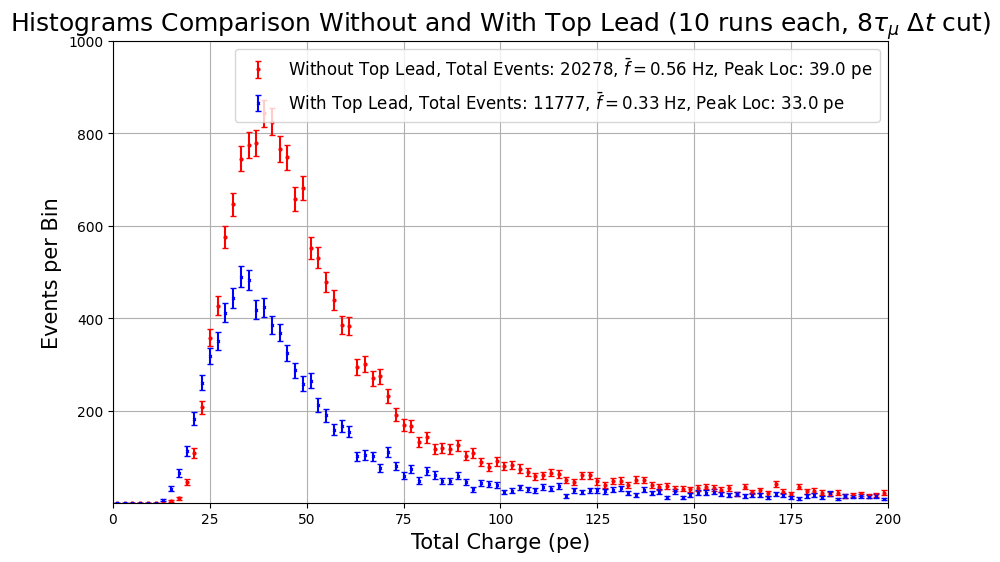

Runs without top lead: 14977-14986
Runs with top lead: 23163-23172


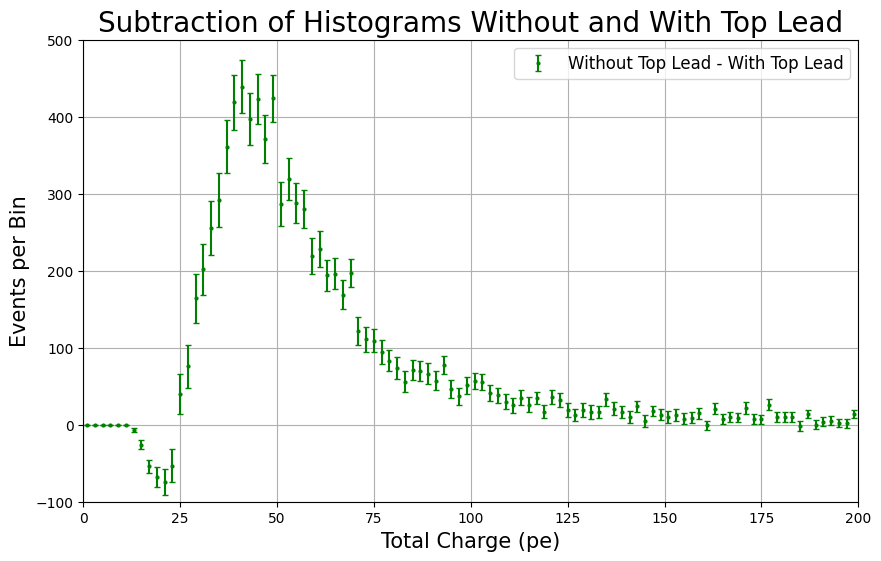

In [14]:
#compare without top lead: 05/31/2024 and with top lead: 06/01/2025 data
import numpy as np
import matplotlib.pyplot as plt
file_no_top = '/raid1/genli/Data_D2O/M1_data/analysis_14977-14986_M1_20251118-163356_8tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
file_with_top = '/raid1/genli/Data_D2O/M1_data/analysis_23163-23172_M1_20251118-001434_8tau/MASTER_RESULTS/aggregated_total_pe_M1.pkl'
data_no_top = np.load(file_no_top, allow_pickle=True)
data_with_top = np.load(file_with_top, allow_pickle=True)
centers_no_top = data_no_top['centers']
numpe_no_top = data_no_top['histograms']['Master Runs 14977-14986']
err_no_top = data_no_top['errors']['Master Runs 14977-14986']
centers_with_top = data_with_top['centers']
numpe_with_top = data_with_top['histograms']['Master Runs 23163-23172']
err_with_top = data_with_top['errors']['Master Runs 23163-23172']   
total_events_no_top = np.sum(numpe_no_top)
total_events_with_top = np.sum(numpe_with_top)
peakloc_no_top = centers_no_top[np.argmax(numpe_no_top)]
peakloc_with_top = centers_with_top[np.argmax(numpe_with_top)]
# print(data_no_top)
#Plotting the histograms for different dt cuts
plt.figure(figsize=(10, 6))
plt.errorbar(centers_no_top, numpe_no_top, yerr=err_no_top, fmt='o', label=f'Without Top Lead, Total Events: {total_events_no_top}, $\\bar{{f}} = {total_events_no_top/36000:.2f}$ Hz, Peak Loc: {peakloc_no_top} pe', color='red', markersize=2, capsize=2)
plt.errorbar(centers_with_top, numpe_with_top, yerr=err_with_top, fmt='x', label=f'With Top Lead, Total Events: {total_events_with_top}, $\\bar{{f}} = {total_events_with_top/36000:.2f}$ Hz, Peak Loc: {peakloc_with_top} pe', color='blue', markersize=2, capsize=2)
plt.title('Histograms Comparison Without and With Top Lead (10 runs each, 8$\\tau_\\mu$ $\\Delta t$ cut)', fontsize=18)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
# plt.yscale('log', base=10)
plt.xlim(0, 200)
plt.ylim(1, 1e3)
plt.legend(fontsize=12)
plt.grid()
plt.show()
#print runs numbers
print("Runs without top lead: 14977-14986")
print("Runs with top lead: 23163-23172")

#plotsubtraction histograms
plt.figure(figsize=(10, 6))
plt.errorbar(centers_no_top, numpe_no_top - numpe_with_top, yerr=np.sqrt(err_no_top**2 + err_with_top**2), fmt='o', label='Without Top Lead - With Top Lead', color='green', markersize=2, capsize=2)
plt.title('Subtraction of Histograms Without and With Top Lead', fontsize=20)
plt.xlabel('Total Charge (pe)', fontsize=15)
plt.ylabel('Events per Bin', fontsize=15)
# plt.yscale('log', base=10)
plt.xlim(0, 200)
plt.ylim(-100, 500)
plt.legend(fontsize=12)
plt.grid()
plt.show()